# Adversarial Training: PGD-AT and TRADES on TrafficNet (GTSRB)

This notebook closes the loop between attack and defense with the only technique in this repo that changes the model itself: **adversarial training**. Instead of transforming inputs at inference time (`01_preprocessing_defenses.ipynb`) or just detecting attacks (`02_detection.ipynb`), we fine-tune the classifier so that its decision boundary is robust by construction.

**Scope:** this is done on **TrafficNet (GTSRB)** only, not the three ImageNet models used everywhere else in the repo. MobileNetV2/EfficientNetB0/InceptionV3 are pretrained on 1000 ImageNet classes; adversarially retraining them from scratch is far beyond what a personal project can run on CPU. TrafficNet is a small, 43-class model already in this repo (`dashboard/models/traffic_sign_model.h5`), which makes it the realistic target for a from-scratch robust training experiment.

We implement two adversarial training objectives, both fine-tuned starting from the existing baseline checkpoint:
* **PGD-AT** (Madry et al., 2018): train directly on PGD adversarial examples instead of clean images.
* **TRADES** (Zhang et al., 2019): train on a loss that explicitly trades off natural accuracy against robustness via a KL-divergence regularizer.

**Scale:** raised from the initial validation pass (860 training images, 3 epochs, FGSM/PGD only) to a more meaningful benchmark: a larger stratified subset of GTSRB, more epochs, and the *full* attack roster used throughout this repo (FGSM, PGD, DeepFool, C&W, Targeted I-FGSM, plus Square Attack as a representative black-box check) evaluated before and after training. All the constants controlling this live in the Configuration cell below, so the scale can be dialled back down for a quick smoke test or pushed further if more compute is available. At this scale, expect the full notebook to run for several hours on a CPU-only machine; if that is impractical, the natural alternative is running it on a GPU runtime such as Google Colab instead, since nothing here depends on the local filesystem beyond the GTSRB data and the baseline `.h5` model, both of which are small enough to upload.

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import time

### Dataset
GTSRB (German Traffic Sign Recognition Benchmark, CC-BY 4.0, [Zenodo record 13741936](https://zenodo.org/records/13741936)) is downloaded separately into `gtsrb_data/` (git-ignored, ~320MB), not part of the repository. `Train/<class_id>/*.png` holds the labeled training images across the 43 classes; we draw a stratified subset from it for both training and held-out evaluation.

In [2]:
GTSRB_DIR = 'gtsrb_data'
TRAIN_DIR = os.path.join(GTSRB_DIR, 'Train')
NUM_CLASSES = 43

signnames_df = pd.read_csv(os.path.join(GTSRB_DIR, 'signnames.csv'))
CLASS_NAMES = dict(zip(signnames_df['ClassId'], signnames_df['SignName']))

if not os.path.isdir(TRAIN_DIR):
    raise FileNotFoundError(
        f"'{TRAIN_DIR}' not found. Download and extract the GTSRB dataset from "
        "https://zenodo.org/records/13741936/files/data.zip into 'defenses/gtsrb_data/' first."
    )

### Configuration
Every constant controlling scale and attack strength lives here. `IMAGES_PER_CLASS_TRAIN`/`IMAGES_PER_CLASS_EVAL` control the stratified subset size (raise them, and `AT_EPOCHS`, once this first pass is validated). `AT_EPSILON` matches the $\varepsilon=0.03$ used as the "moderate" setting throughout `attacks/*.ipynb` and `robustness_evaluation/10_generate_adversarial_dataset.ipynb`.

In [3]:
# --- Data scale (raised from the initial validation pass once it was confirmed to work end to end) ---
IMAGES_PER_CLASS_TRAIN = 80   # -> ~3440 training images across 43 classes
IMAGES_PER_CLASS_EVAL = 15    # -> ~645 held-out evaluation images
BATCH_SIZE = 16

# --- Model I/O (matches dashboard/utils/model_loader.py's TrafficNet config) ---
TARGET_SIZE = (224, 224)
CLIP_MIN, CLIP_MAX = 0.0, 1.0
BASELINE_MODEL_PATH = '../dashboard/models/traffic_sign_model.h5'

# --- Adversarial training hyperparameters ---
AT_EPOCHS = 15
AT_EPSILON = 0.03
AT_ALPHA = AT_EPSILON / 2.0
AT_PGD_STEPS = 5             # fewer than the 10 used at evaluation time - the standard AT speed/robustness trade-off
AT_LEARNING_RATE = 1e-4
TRADES_BETA = 6.0            # matches the value used in Zhang et al., 2019

# --- Evaluation attack strength (kept identical before/after for a fair comparison) ---
EVAL_EPSILON = 0.03
EVAL_PGD_STEPS = 10

# --- Wider attack battery ---
# DeepFool, C&W, Targeted I-FGSM and Square Attack all cost one or more full forward/backward passes
# *per image, with no batching* (see attacks/whitebox/03_DeepFool.ipynb, 04_C&W.ipynb,
# 05_TargetedIFGSM.ipynb, attacks/blackbox/01_SquareAttack.ipynb), unlike the batched FGSM/PGD above.
# Their budgets below are reduced from each notebook's own default for the same reason NES/Boundary
# Attack already get reduced query budgets elsewhere in this repo: a given budget is affordable for a
# handful of images, not for hundreds of images x 3 models.
DEEPFOOL_NUM_CLASSES = 10     # restrict to the top-10 candidate classes, the function's own intended use
DEEPFOOL_MAX_ITER = 20
CW_MAX_ITERS = 50             # down from the notebook's own default of 200
CW_LEARNING_RATE = 0.01
TIFGSM_MAX_ITER = 40          # down from the notebook's own default of 1000
TIFGSM_BASE_ALPHA = 0.01
TIFGSM_TARGET_CONFIDENCE = 0.9
SQUARE_QUERY_BUDGET = 200     # down from the notebook's own default of 1000
SQUARE_P_INIT = 0.2

# NES and Boundary Attack are deliberately left out of this comparison entirely: both need hundreds to
# thousands of full forward passes *per image* even at their own already-reduced budgets (see
# attacks/blackbox/02_NES.ipynb, 03_BoundaryAttack.ipynb), which is a different order of cost again.

# Even at the reduced budgets above, running 4 extra per-image attacks x 3 models over the full eval set
# would dominate this notebook's runtime for a comparatively small addition to what the result shows.
# FGSM/PGD/clean accuracy still run on the full eval set below (they are batched and cheap); DeepFool,
# C&W, Targeted I-FGSM and Square Attack run on a smaller stratified sub-sample instead.
SLOW_ATTACK_EVAL_SIZE = 150   # roughly 3 images per class

### Stratified Train/Eval Split
We sample the same fixed number of images per class for training and, separately, for evaluation, so no class dominates the (small) subset and no image is used for both training and testing. A further, smaller stratified sub-sample of the eval set (`SLOW_ATTACK_EVAL_SIZE`) is set aside for DeepFool/C&W/Targeted I-FGSM/Square Attack, the four attacks that run one image at a time instead of as a batch.

In [4]:
def collect_stratified_subset(train_dir, per_class_train, per_class_eval, seed=42):
    rng = np.random.default_rng(seed)
    train_paths, train_labels, eval_paths, eval_labels = [], [], [], []

    for class_id in range(NUM_CLASSES):
        files = sorted(glob.glob(os.path.join(train_dir, str(class_id), '*.png')))
        rng.shuffle(files)
        needed = per_class_train + per_class_eval
        chosen = files[:needed]

        class_train = chosen[:per_class_train]
        class_eval = chosen[per_class_train:per_class_train + per_class_eval]

        train_paths += class_train
        train_labels += [class_id] * len(class_train)
        eval_paths += class_eval
        eval_labels += [class_id] * len(class_eval)

    return train_paths, train_labels, eval_paths, eval_labels

train_paths, train_labels, eval_paths, eval_labels = collect_stratified_subset(
    TRAIN_DIR, IMAGES_PER_CLASS_TRAIN, IMAGES_PER_CLASS_EVAL
)
print(f"Train subset: {len(train_paths)} images | Eval subset: {len(eval_paths)} images (both stratified across {NUM_CLASSES} classes)")

def load_gtsrb_image(path):
    img_raw = tf.io.read_file(path)
    img = tf.image.decode_png(img_raw, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, TARGET_SIZE)
    return img / 255.0  # matches preprocess_gtsrb() in dashboard/utils/model_loader.py

def build_dataset(paths, labels, batch_size, shuffle):
    labels_onehot = tf.one_hot(labels, NUM_CLASSES)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels_onehot))
    ds = ds.map(lambda p, l: (load_gtsrb_image(p), l), num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = build_dataset(train_paths, train_labels, BATCH_SIZE, shuffle=True)
eval_ds = build_dataset(eval_paths, eval_labels, BATCH_SIZE, shuffle=False)

def stratified_subsample(paths, labels, per_class, seed=123):
    """Further stratified sub-sample of an already-stratified list, used to cap the cost of the
    per-image attacks below without breaking the per-class balance."""
    rng = np.random.default_rng(seed)
    by_class = {}
    for p, l in zip(paths, labels):
        by_class.setdefault(l, []).append(p)
    sub_paths, sub_labels = [], []
    for class_id, class_paths in by_class.items():
        chosen = rng.choice(class_paths, size=min(per_class, len(class_paths)), replace=False)
        sub_paths += list(chosen)
        sub_labels += [class_id] * len(chosen)
    return sub_paths, sub_labels

SLOW_PER_CLASS = max(1, SLOW_ATTACK_EVAL_SIZE // NUM_CLASSES)
slow_eval_paths, slow_eval_labels = stratified_subsample(eval_paths, eval_labels, SLOW_PER_CLASS)
slow_eval_ds = build_dataset(slow_eval_paths, slow_eval_labels, batch_size=1, shuffle=False)
print(f"Slow-attack eval subset: {len(slow_eval_paths)} images ({SLOW_PER_CLASS}/class) for DeepFool/C&W/Targeted-IFGSM/Square Attack")

Train subset: 3440 images | Eval subset: 645 images (both stratified across 43 classes)
Slow-attack eval subset: 129 images (3/class) for DeepFool/C&W/Targeted-IFGSM/Square Attack


### Baseline Model
We load the existing `traffic_sign_model.h5` as-is: this is the "before" side of the comparison, and also the starting checkpoint that both PGD-AT and TRADES fine-tune from.

In [5]:
baseline_model = tf.keras.models.load_model(BASELINE_MODEL_PATH)
baseline_model.trainable = True  # we are about to fine-tune copies of it
print(f"Loaded baseline model - input {baseline_model.input_shape}, output {baseline_model.output_shape}")

Loaded baseline model - input (None, 224, 224, 3), output (None, 43)


### Attack Functions (for evaluation)
FGSM and PGD are re-implemented here in batched form (same math as `attacks/whitebox/01_FGSM.ipynb`/`02_PGD.ipynb`) since they run over the full eval set. DeepFool, C&W, Targeted I-FGSM and Square Attack are imported directly from the `advml_vision` package instead of being re-implemented, since they already exist there in exactly the same form used throughout `attacks/whitebox/` and `attacks/blackbox/`. All of this is used purely to *measure* robustness before and after training, not to generate the training-time adversarial examples, which live in the PGD-AT/TRADES cell below.

In [6]:
from advml_vision.attacks import deepfool_attack, cw_attack, targeted_ifgsm_attack, square_attack

loss_object = tf.keras.losses.CategoricalCrossentropy()

def fgsm_attack(img, label, epsilon, model, clip_min, clip_max):
    with tf.GradientTape() as tape:
        tape.watch(img)
        pred = model(img, training=False)
        loss = loss_object(label, pred)
    grad = tape.gradient(loss, img)
    return tf.clip_by_value(img + epsilon * tf.sign(grad), clip_min, clip_max)

def pgd_attack(img, label, epsilon, model, clip_min, clip_max, iters=10):
    alpha = epsilon / (iters / 2.0)
    adv_img = tf.identity(img)
    for _ in range(iters):
        with tf.GradientTape() as tape:
            tape.watch(adv_img)
            pred = model(adv_img, training=False)
            loss = loss_object(label, pred)
        grad = tape.gradient(loss, adv_img)
        adv_img = adv_img + alpha * tf.sign(grad)
        perturbation = tf.clip_by_value(adv_img - img, -epsilon, epsilon)
        adv_img = tf.clip_by_value(img + perturbation, clip_min, clip_max)
    return adv_img

def evaluate_robustness(model, dataset, slow_dataset, epsilon=EVAL_EPSILON, pgd_iters=EVAL_PGD_STEPS):
    """Clean accuracy plus FGSM/PGD Attack Success Rate over the full (batched) eval set, plus
    DeepFool/C&W/Targeted-IFGSM/Square Attack ASR over the smaller `slow_dataset` sub-sample (see the
    Configuration cell for why those four run at a smaller scale)."""
    total, clean_correct, fgsm_correct, pgd_correct = 0, 0, 0, 0

    for x, y in dataset:
        true_idx = tf.argmax(y, axis=-1)

        clean_preds = model(x, training=False)
        clean_correct += int(tf.reduce_sum(tf.cast(tf.argmax(clean_preds, axis=-1) == true_idx, tf.int32)))

        x_fgsm = fgsm_attack(x, y, epsilon, model, CLIP_MIN, CLIP_MAX)
        fgsm_preds = model(x_fgsm, training=False)
        fgsm_correct += int(tf.reduce_sum(tf.cast(tf.argmax(fgsm_preds, axis=-1) == true_idx, tf.int32)))

        x_pgd = pgd_attack(x, y, epsilon, model, CLIP_MIN, CLIP_MAX, iters=pgd_iters)
        pgd_preds = model(x_pgd, training=False)
        pgd_correct += int(tf.reduce_sum(tf.cast(tf.argmax(pgd_preds, axis=-1) == true_idx, tf.int32)))

        total += x.shape[0]

    # DeepFool, C&W, Targeted I-FGSM and Square Attack operate on one image at a time (batch size 1),
    # so they run over the smaller slow_dataset instead of being folded into the loop above.
    slow_total = 0
    slow_correct = {'DeepFool': 0, 'CW': 0, 'TargetedIFGSM': 0, 'Square': 0}

    for x, y in slow_dataset:
        true_i = int(tf.argmax(y[0]))

        adv_deepfool = deepfool_attack(x, model, CLIP_MIN, CLIP_MAX, num_classes=DEEPFOOL_NUM_CLASSES, max_iter=DEEPFOOL_MAX_ITER)
        slow_correct['DeepFool'] += int(tf.argmax(model(adv_deepfool, training=False)[0]) == true_i)

        adv_cw = cw_attack(x, y, model, CLIP_MIN, CLIP_MAX, learning_rate=CW_LEARNING_RATE, max_iters=CW_MAX_ITERS)
        slow_correct['CW'] += int(tf.argmax(model(adv_cw, training=False)[0]) == true_i)

        # Targeted at a fixed "next class" target (same convention as attacks/whitebox/05_TargetedIFGSM.ipynb).
        # Counted here the same way as every other ASR above (any wrong prediction counts as a success),
        # for comparability with the untargeted attacks, not the stricter "hit the exact target class" metric.
        target_i = (true_i + 1) % NUM_CLASSES
        target_onehot = tf.one_hot([target_i], NUM_CLASSES)
        adv_tifgsm = targeted_ifgsm_attack(
            x, target_onehot, model, CLIP_MIN, CLIP_MAX, eps_scale=1.0,
            base_alpha=TIFGSM_BASE_ALPHA, target_confidence=TIFGSM_TARGET_CONFIDENCE, max_iter=TIFGSM_MAX_ITER,
        )
        slow_correct['TargetedIFGSM'] += int(tf.argmax(model(adv_tifgsm, training=False)[0]) == true_i)

        adv_square, _ = square_attack(
            x, true_i, model, epsilon, CLIP_MIN, CLIP_MAX,
            query_budget=SQUARE_QUERY_BUDGET, p_init=SQUARE_P_INIT,
        )
        slow_correct['Square'] += int(tf.argmax(model(adv_square, training=False)[0]) == true_i)

        slow_total += 1

    return {
        'Clean_Accuracy': 100 * clean_correct / total,
        'FGSM_ASR': 100 * (1 - fgsm_correct / total),
        'PGD_ASR': 100 * (1 - pgd_correct / total),
        'DeepFool_ASR': 100 * (1 - slow_correct['DeepFool'] / slow_total),
        'CW_ASR': 100 * (1 - slow_correct['CW'] / slow_total),
        'TargetedIFGSM_ASR': 100 * (1 - slow_correct['TargetedIFGSM'] / slow_total),
        'Square_ASR': 100 * (1 - slow_correct['Square'] / slow_total),
    }

### Baseline Robustness (Before Adversarial Training)
This is the reference point every subsequent number in this notebook is compared against.

In [7]:
print("Evaluating BASELINE model robustness...")
baseline_results = evaluate_robustness(baseline_model, eval_ds, slow_eval_ds)
print(baseline_results)

Evaluating BASELINE model robustness...
{'Clean_Accuracy': 68.37209302325581, 'FGSM_ASR': 90.23255813953487, 'PGD_ASR': 100.0, 'DeepFool_ASR': 87.59689922480621, 'CW_ASR': 96.12403100775194, 'TargetedIFGSM_ASR': 100.0, 'Square_ASR': 98.44961240310077}


### PGD-AT and TRADES
**PGD-AT** (Madry et al., 2018) simply replaces clean training images with PGD adversarial examples generated on-the-fly against the model's current weights, then trains on those:
$$\min_\theta \; \mathbb{E}_{(x,y)} \Big[ \max_{\lVert \delta \rVert_\infty \le \varepsilon} J\big(\theta, x+\delta, y\big) \Big]$$

**TRADES** (Zhang et al., 2019) instead keeps a natural-accuracy term and adds a separate robustness regularizer, weighted by $\beta$, that penalizes the model for disagreeing between a clean image and its worst-case neighbor within the $\varepsilon$-ball:
$$\min_\theta \; \mathbb{E}_{(x,y)} \Big[ J(\theta, x, y) + \beta \cdot \max_{\lVert \delta \rVert_\infty \le \varepsilon} \mathrm{KL}\big(f_\theta(x) \,\Vert\, f_\theta(x+\delta)\big) \Big]$$
In both cases the inner maximization is approximated with a short PGD loop, exactly like the outer evaluation attacks but with fewer steps for training-time speed.

In [8]:
def pgd_attack_train(model, x, y_onehot, epsilon, alpha, iters, clip_min, clip_max):
    """Same PGD loop as above, but starting from a random point in the epsilon-ball (Madry et al.'s recommended init)."""
    x_adv = x + tf.random.uniform(tf.shape(x), -epsilon, epsilon)
    x_adv = tf.clip_by_value(x_adv, clip_min, clip_max)
    for _ in range(iters):
        with tf.GradientTape() as tape:
            tape.watch(x_adv)
            preds = model(x_adv, training=False)
            loss = loss_object(y_onehot, preds)
        grad = tape.gradient(loss, x_adv)
        x_adv = x_adv + alpha * tf.sign(grad)
        perturbation = tf.clip_by_value(x_adv - x, -epsilon, epsilon)
        x_adv = tf.clip_by_value(x + perturbation, clip_min, clip_max)
    return tf.stop_gradient(x_adv)

def pgd_at_train_step(model, optimizer, x, y_onehot):
    x_adv = pgd_attack_train(model, x, y_onehot, AT_EPSILON, AT_ALPHA, AT_PGD_STEPS, CLIP_MIN, CLIP_MAX)
    with tf.GradientTape() as tape:
        preds_adv = model(x_adv, training=True)
        loss = loss_object(y_onehot, preds_adv)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

def trades_inner_maximization(model, x, epsilon, alpha, iters, clip_min, clip_max):
    """Finds the point in the epsilon-ball that maximizes disagreement (KL divergence) with the natural prediction."""
    natural_probs = tf.stop_gradient(model(x, training=False))
    x_adv = x + 0.001 * tf.random.normal(tf.shape(x))
    x_adv = tf.clip_by_value(x_adv, clip_min, clip_max)
    kl = tf.keras.losses.KLDivergence()
    for _ in range(iters):
        with tf.GradientTape() as tape:
            tape.watch(x_adv)
            adv_probs = model(x_adv, training=False)
            loss_kl = kl(natural_probs, adv_probs)
        grad = tape.gradient(loss_kl, x_adv)
        x_adv = x_adv + alpha * tf.sign(grad)
        perturbation = tf.clip_by_value(x_adv - x, -epsilon, epsilon)
        x_adv = tf.clip_by_value(x + perturbation, clip_min, clip_max)
    return tf.stop_gradient(x_adv)

def trades_train_step(model, optimizer, x, y_onehot):
    x_adv = trades_inner_maximization(model, x, AT_EPSILON, AT_ALPHA, AT_PGD_STEPS, CLIP_MIN, CLIP_MAX)
    kl = tf.keras.losses.KLDivergence()
    with tf.GradientTape() as tape:
        natural_preds = model(x, training=True)
        adv_preds = model(x_adv, training=True)
        loss_natural = loss_object(y_onehot, natural_preds)
        loss_robust = kl(natural_preds, adv_preds)
        total_loss = loss_natural + TRADES_BETA * loss_robust
    grads = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return total_loss

### Training Loop
Both objectives fine-tune an independent copy of the baseline's weights, so the three models being compared (Baseline / PGD-AT / TRADES) all start from the exact same point.

In [9]:
def adversarial_finetune(model, dataset, train_step_fn, epochs):
    optimizer = tf.keras.optimizers.Adam(learning_rate=AT_LEARNING_RATE)
    history = []
    for epoch in range(epochs):
        start = time.time()
        losses = [float(train_step_fn(model, optimizer, x, y)) for x, y in dataset]
        avg_loss = float(np.mean(losses))
        history.append(avg_loss)
        print(f"  Epoch {epoch + 1}/{epochs} - avg loss: {avg_loss:.4f} - {time.time() - start:.1f}s")
    return history

print("Adversarially training with PGD-AT (Madry et al., 2018)...")
pgd_at_model = tf.keras.models.clone_model(baseline_model)
pgd_at_model.set_weights(baseline_model.get_weights())
pgd_at_history = adversarial_finetune(pgd_at_model, train_ds, pgd_at_train_step, AT_EPOCHS)
pgd_at_model.save('../dashboard/models/traffic_sign_model_pgdat.h5')

print("\nAdversarially training with TRADES (Zhang et al., 2019)...")
trades_model = tf.keras.models.clone_model(baseline_model)
trades_model.set_weights(baseline_model.get_weights())
trades_history = adversarial_finetune(trades_model, train_ds, trades_train_step, AT_EPOCHS)
trades_model.save('../dashboard/models/traffic_sign_model_trades.h5')

Adversarially training with PGD-AT (Madry et al., 2018)...
  Epoch 1/15 - avg loss: 47.1559 - 1175.0s
  Epoch 2/15 - avg loss: 42.1299 - 1178.8s
  Epoch 3/15 - avg loss: 39.7502 - 1177.1s
  Epoch 4/15 - avg loss: 38.2290 - 1204.3s
  Epoch 5/15 - avg loss: 36.8293 - 1173.3s
  Epoch 6/15 - avg loss: 35.5018 - 1175.9s
  Epoch 7/15 - avg loss: 34.2472 - 1178.2s
  Epoch 8/15 - avg loss: 33.2253 - 1621.4s
  Epoch 9/15 - avg loss: 32.4872 - 1194.6s
  Epoch 10/15 - avg loss: 31.1757 - 1187.7s
  Epoch 11/15 - avg loss: 30.3307 - 1208.1s
  Epoch 12/15 - avg loss: 29.0164 - 1179.4s
  Epoch 13/15 - avg loss: 28.1893 - 1195.9s
  Epoch 14/15 - avg loss: 27.6005 - 1162.0s


  Epoch 15/15 - avg loss: 27.0284 - 1197.1s

Adversarially training with TRADES (Zhang et al., 2019)...
  Epoch 1/15 - avg loss: 86.0370 - 1469.7s
  Epoch 2/15 - avg loss: 85.5367 - 1485.4s
  Epoch 3/15 - avg loss: 83.7149 - 1489.3s
  Epoch 4/15 - avg loss: 75.8770 - 1482.8s
  Epoch 5/15 - avg loss: 47.6113 - 1490.9s
  Epoch 6/15 - avg loss: 33.0075 - 1493.5s
  Epoch 7/15 - avg loss: 27.2164 - 1512.1s
  Epoch 8/15 - avg loss: 24.3839 - 1507.1s
  Epoch 9/15 - avg loss: 21.2143 - 1515.1s
  Epoch 10/15 - avg loss: 19.1010 - 1496.4s
  Epoch 11/15 - avg loss: 17.5170 - 1487.9s
  Epoch 12/15 - avg loss: 16.1677 - 1820.9s
  Epoch 13/15 - avg loss: 15.5386 - 1476.4s
  Epoch 14/15 - avg loss: 14.6220 - 1468.6s


  Epoch 15/15 - avg loss: 13.9565 - 1462.7s


### Robustness After Adversarial Training
Same attacks, same $\varepsilon$, same held-out evaluation set as the baseline measurement above: the only thing that changed is the model's weights.

In [10]:
print("Evaluating PGD-AT model robustness...")
pgd_at_results = evaluate_robustness(pgd_at_model, eval_ds, slow_eval_ds)
print(pgd_at_results)

print("\nEvaluating TRADES model robustness...")
trades_results = evaluate_robustness(trades_model, eval_ds, slow_eval_ds)
print(trades_results)

Evaluating PGD-AT model robustness...
{'Clean_Accuracy': 71.16279069767442, 'FGSM_ASR': 82.01550387596899, 'PGD_ASR': 100.0, 'DeepFool_ASR': 85.27131782945736, 'CW_ASR': 96.89922480620154, 'TargetedIFGSM_ASR': 100.0, 'Square_ASR': 97.67441860465115}

Evaluating TRADES model robustness...
{'Clean_Accuracy': 2.3255813953488373, 'FGSM_ASR': 97.67441860465115, 'PGD_ASR': 99.84496124031008, 'DeepFool_ASR': 84.49612403100775, 'CW_ASR': 97.67441860465115, 'TargetedIFGSM_ASR': 100.0, 'Square_ASR': 97.67441860465115}


### Before vs. After: Does Adversarial Training Work?
The comparison this whole repo has been building towards: the same attacks, against the same held-out images, before and after adversarial training.

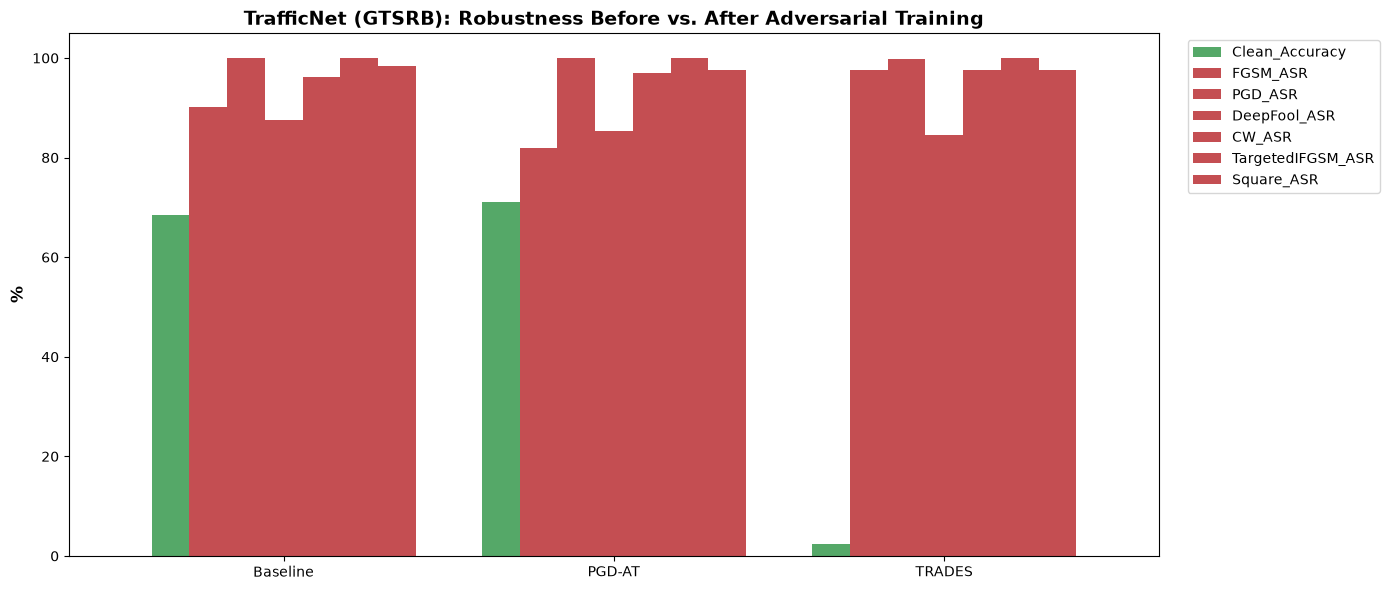

,Clean_Accuracy,FGSM_ASR,PGD_ASR,DeepFool_ASR,CW_ASR,TargetedIFGSM_ASR,Square_ASR
Baseline,68.4,90.2,100.0,87.6,96.1,100.0,98.4
PGD-AT,71.2,82.0,100.0,85.3,96.9,100.0,97.7
TRADES,2.3,97.7,99.8,84.5,97.7,100.0,97.7


In [11]:
results_df = pd.DataFrame({
    'Baseline': baseline_results,
    'PGD-AT': pgd_at_results,
    'TRADES': trades_results,
}).T

results_df.to_csv('adversarial_training_results.csv')

n_metrics = len(results_df.columns)
colors = ['#55A868'] + ['#C44E52'] * (n_metrics - 1)  # green = clean accuracy, red = every ASR

ax = results_df.plot(kind='bar', figsize=(14, 6), width=0.8, color=colors)
ax.set_ylabel('%', fontsize=12, fontweight='bold')
ax.set_title('TrafficNet (GTSRB): Robustness Before vs. After Adversarial Training', fontsize=14, fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

results_df.round(1)